In [64]:
import numpy as np, pandas as pd, yfinance as yf, matplotlib.pyplot as plt

### Load Data

In [68]:
px = yf.download(["GLD", "USO"], start="2007-01-01", end="2014-12-31", auto_adjust=True)["Close"].dropna()
x, y = px["GLD"], px["USO"]

[*********************100%***********************]  2 of 2 completed


### Rolling hedge ratio

In [69]:
lb = 20
cov = x.rolling(lb).cov(y)
var = x.rolling(lb).var()
hr = cov / var

### Spread and z-score

In [70]:
s = y - hr * x
z = (s - s.rolling(lb).mean()) / s.rolling(lb).std()

(s) spread is the portfolio market value (long 1 USO, short hr GLD). The z-score says how many standard deviations it sits from its 20-day mean.

drop the warm-up rows (lb)

In [71]:
ok = z.notna()
px, hr, z = px[ok], hr[ok], z[ok]
x, y = px["GLD"], px["USO"]

### Positions (entry 1, exit 0)

In [72]:
def positions(z, entry=1, exit_=0):
    pos, out = 0, []
    for v in z:
        if np.isnan(v): out.append(0); continue
        if pos == 0:
            pos = 1 if v < -entry else -1 if v > entry else 0
        elif pos == 1 and v > -exit_:
            pos = 0
        elif pos == -1 and v < exit_:
            pos = 0
        out.append(pos)
    return pd.Series(out, index=z.index)

units = positions(z)

Long the spread when z < -1, short when z > 1, flat when z crosses back through 0.A plain loop is easier to read, and needed for scaling in.

### P&L

In [73]:
legs = pd.DataFrame({"GLD":-hr * x, "USO": y})
pos_d = legs.mul(units, axis=0)
ret_legs = px[["GLD","USO"]].pct_change()

In [74]:
pnl = (pos_d.shift(1) * ret_legs.values).sum(axis=1)
ret = (pnl / pos_d.shift(1).abs().sum(axis=1)).iloc[1:].fillna(0)

### Results

APR=0.153 Sharpe=0.92


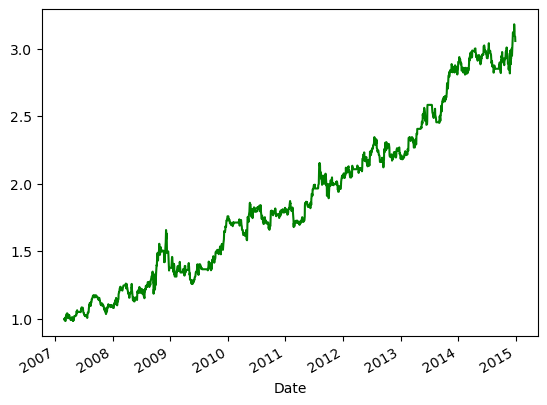

In [78]:
def stats(ret):
    ann = (1 + ret).prod() ** (252 / len(ret)) - 1
    sr = np.sqrt(252) * ret.mean() / ret.std()
    return f"APR={ann:.3f} Sharpe={sr:.2f}"

print(stats(ret))
(1 + ret).cumprod().plot(color="green")
plt.show()

### Scaling in

In [76]:
def positions_scaled(z, levels=(1, 2, 3), exit_=0):
    pos, out = 0, []
    for v in z:
        if np.isnan(v): out.append(0); continue
        n = sum(abs(v) > L for L in levels)          # how many levels crossed
        if pos == 0 and n > 0:
            pos = -np.sign(v) * n
        elif pos != 0:
            if (pos > 0 and v > -exit_) or (pos < 0 and v < exit_):
                pos = 0                              # full exit at mean
            elif n > abs(pos) and np.sign(v) == -np.sign(pos):
                pos = -np.sign(v) * n                # add, never trim
        out.append(pos)
    return pd.Series(out, index=z.index)

In [77]:
def run(units, cap=3):
    pos_d = legs.mul(units, axis=0)
    pnl = (pos_d.shift(1) * ret_legs).sum(axis=1)
    capital = cap * legs.abs().sum(axis=1).shift(1)   # fixed 3-unit budget
    return (pnl / capital).iloc[1:].fillna(0)

print("all-in (3 units at z=1):", stats(run(positions(z) * 3)))
print("scaled (1/2/3 units)   :", stats(run(positions_scaled(z))))

all-in (3 units at z=1): APR=0.153 Sharpe=0.92
scaled (1/2/3 units)   : APR=0.064 Sharpe=0.61
